# 70 - SNP directos con red neuronal tabular (Keras)

## 1) Introducción breve

Este cuaderno implementa una **prueba piloto metodológicamente controlada** de deep learning para predicción genómica en cebada usando SNPs directos del archivo `.raw` de PLINK (`--export A`).

- El `.raw` se trata como **datos estructurados/tabulares**: cada SNP es una variable numérica por individuo.
- **No se usan arquitecturas de imagen** (`keras.applications`, CNN 2D, modelos preentrenados de visión), porque no hay estructura espacial de píxel que justificar.
- Se usan dos **MLP pequeñas y regularizadas** (L2 + BatchNorm + Dropout) para explorar capacidad no lineal sin sobredimensionar complejidad.

Diseño de validación:
- **CV externa 5-fold** para comparabilidad con el proyecto.
- Dentro de cada fold externo: **split train/validation interno (80/20)** para callbacks (early stopping, reducción LR y checkpoint).
- Todo el preprocesado (imputación/escalado) se ajusta solo con train interno de cada fold para evitar leakage.

> Nota: no se usa nested CV en esta versión, pero la estructura se separa explícitamente para facilitar la migración posterior.


In [1]:
# 2) Carga de librerías, rutas y parámetros globales
from pathlib import Path
import re
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
except Exception as exc:
    raise ImportError(
        "TensorFlow/Keras no está disponible en este entorno. Instala tensorflow para ejecutar este notebook."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# Reproducibilidad
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

# =========================
# Rutas relativas del proyecto
# =========================
RAW_REL = Path("merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw")
PHENO_REL = Path("pheno_data/BLUEs_across_env.tsv")
META_REL = Path("pheno_data/giae121_supplemental_file.xlsx")
META_HEADER_ROW = 2

OUTPUT_REL = Path("results/nn_snp_pilot")
CHECKPOINT_REL = OUTPUT_REL / "checkpoints"

# =========================
# Traits del piloto
# =========================
TRAITS = [
    "lodging",
    "ramularia_collo_cygni",
]

# =========================
# Diseño CV y entrenamiento
# =========================
OUTER_SPLITS = 5
INNER_VAL_SIZE = 0.20  # split interno train/val dentro de cada fold externo
MAX_EPOCHS = 300

LEARNING_RATES = [1e-3, 5e-4]
BATCH_SIZES = [16, 32]
MODEL_NAMES = ["mlp_a", "mlp_b"]

EARLY_STOP_PATIENCE = 30
REDUCE_LR_PATIENCE = 10
REDUCE_LR_FACTOR = 0.5
MIN_LR = 1e-6

VERBOSE_FIT = 0

# =========================
# Columnas de identificación del .raw
# =========================
RAW_ID_COLS = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.18.0
NumPy: 2.0.2
Pandas: 2.2.3


In [2]:
# 3) Resolución robusta de rutas reales y creación de salida

def resolve_base_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "nested5x3_unificados",
        cwd.parent,
        cwd.parent / "nested5x3_unificados",
    ]
    for base in candidates:
        if (base / RAW_REL).exists() and (base / PHENO_REL).exists() and (base / META_REL).exists():
            return base
    raise FileNotFoundError(
        "No se pudieron resolver las rutas de RAW/PHENO/META. Ejecuta desde la raíz del repo o desde nested5x3_unificados."
    )

BASE_DIR = resolve_base_dir()
RAW_PATH = BASE_DIR / RAW_REL
PHENO_PATH = BASE_DIR / PHENO_REL
META_PATH = BASE_DIR / META_REL

OUTPUT_DIR = BASE_DIR / OUTPUT_REL
CHECKPOINT_DIR = BASE_DIR / CHECKPOINT_REL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAW_PATH:", RAW_PATH)
print("PHENO_PATH:", PHENO_PATH)
print("META_PATH:", META_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados
RAW_PATH: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw
PHENO_PATH: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\pheno_data\BLUEs_across_env.tsv
META_PATH: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\pheno_data\giae121_supplemental_file.xlsx
OUTPUT_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot


In [3]:
# 4) Carga del .raw y detección de SNPs directos
if not RAW_PATH.exists():
    raise FileNotFoundError(f"No se encuentra el .raw: {RAW_PATH}")

raw = pd.read_csv(RAW_PATH, sep=r"\s+")

if "IID" not in raw.columns:
    raise KeyError("La columna IID no existe en el .raw")

ids = raw["IID"].astype(str).str.strip().rename("IID")
if ids.duplicated().any():
    raise ValueError("Hay IID duplicados en el .raw. Resolver antes de modelar.")

meta_cols_present = [c for c in RAW_ID_COLS if c in raw.columns]
snp_cols = [c for c in raw.columns if c not in RAW_ID_COLS]
if not snp_cols:
    raise ValueError("No se detectaron columnas SNP en el .raw")

# Convertimos SNPs a numérico de forma robusta
X_snp = raw[snp_cols].apply(pd.to_numeric, errors="coerce")

non_numeric_after = [c for c in X_snp.columns if not pd.api.types.is_numeric_dtype(X_snp[c])]
if non_numeric_after:
    raise TypeError(f"Persisten SNPs no numéricos tras coerción. Ejemplo: {non_numeric_after[:10]}")

print(f"raw shape: {raw.shape}")
print("meta cols detectadas:", meta_cols_present)
print(f"SNP matrix (n x p): {X_snp.shape}")
print(f"IID únicos: {ids.nunique()} / {len(ids)}")


raw shape: (1110, 61145)
meta cols detectadas: ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
SNP matrix (n x p): (1110, 61139)
IID únicos: 1110 / 1110


In [4]:
# 5) Merge genotipo-fenotipo reutilizando la lógica del 53_snp
if not PHENO_PATH.exists():
    raise FileNotFoundError(f"No se encuentra fenotipo: {PHENO_PATH}")
if not META_PATH.exists():
    raise FileNotFoundError(f"No se encuentra metadata: {META_PATH}")

na_vals = ["", "NA", "NaN", "na", "N/A", "null", "NULL"]
df_pheno = pd.read_csv(PHENO_PATH, sep="	", na_values=na_vals)
meta = pd.read_excel(META_PATH, header=META_HEADER_ROW)
meta = meta.loc[:, ~meta.columns.astype(str).str.contains(r"^Unnamed", regex=True)].copy()

if "genotypes" not in df_pheno.columns:
    raise KeyError("En fenotipo no existe la columna 'genotypes'")

# Resolver IID en metadata
iid_candidates = ["IID", "BioSamples ID", "BioSample ID", "biosamples id", "sample_id", "Sample_ID"]
rename_map = {}
for c in iid_candidates:
    if c in meta.columns:
        rename_map[c] = "IID"
        break
meta = meta.rename(columns=rename_map)
if "IID" not in meta.columns:
    raise KeyError("No se encontró columna IID en metadata")


def norm_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"[^A-Z0-9]+", "", x)
    return x if x else np.nan


meta["IID"] = meta["IID"].astype(str).str.strip()
df_pheno["genotypes"] = df_pheno["genotypes"].astype(str).str.strip()
df_pheno["GENO_NORM"] = df_pheno["genotypes"].apply(norm_name)

candidate_name_cols = ["genotype", "genotype name used for BioSamples", "Genebank name"]
meta_name_cols = [c for c in candidate_name_cols if c in meta.columns]
if not meta_name_cols:
    raise KeyError("No hay columnas útiles para construir puente genotipo -> IID")

bridge_parts = []
for col in meta_name_cols:
    tmp = meta[["IID", col]].copy().rename(columns={col: "GENO_RAW"})
    bridge_parts.append(tmp)

bridge_df = pd.concat(bridge_parts, ignore_index=True)
bridge_df["GENO_NORM"] = bridge_df["GENO_RAW"].apply(norm_name)
bridge_df = bridge_df.dropna(subset=["IID", "GENO_NORM"]).drop_duplicates(["IID", "GENO_NORM"])

# Mantener solo traits del piloto
trait_cols_present = [t for t in TRAITS if t in df_pheno.columns]
missing_traits = [t for t in TRAITS if t not in df_pheno.columns]
if missing_traits:
    raise ValueError(f"Faltan traits en fenotipo: {missing_traits}")

for t in trait_cols_present:
    df_pheno[t] = pd.to_numeric(df_pheno[t], errors="coerce")

pheno_unique = (
    df_pheno.dropna(subset=["GENO_NORM"])
    .groupby("GENO_NORM", as_index=False)[trait_cols_present]
    .mean()
)

iid_pheno = bridge_df[["IID", "GENO_NORM"]].merge(pheno_unique, on="GENO_NORM", how="left")
iid_pheno = iid_pheno.drop_duplicates(subset=["IID"])
iid_pheno = iid_pheno[["IID"] + trait_cols_present].copy()

snp_df = pd.concat([ids, X_snp], axis=1)
model_df = snp_df.merge(iid_pheno, on="IID", how="left")

feature_cols = snp_cols.copy()
traits_disponibles = [t for t in TRAITS if t in model_df.columns]
if not traits_disponibles:
    raise ValueError("No hay traits disponibles tras merge")

print("Columnas puente usadas:", meta_name_cols)
print("Traits disponibles:", traits_disponibles)
print("model_df shape:", model_df.shape)


Columnas puente usadas: ['genotype', 'genotype name used for BioSamples', 'Genebank name']
Traits disponibles: ['lodging', 'ramularia_collo_cygni']
model_df shape: (1110, 61142)


In [5]:
# 6) Resumen inicial obligatorio (shape X, nº SNPs, individuos y nº por trait)
X_full = model_df[feature_cols]

n_individuos_merge = int(model_df.shape[0])
n_snps = int(len(feature_cols))
shape_x = X_full.shape

counts_trait = []
for trait in traits_disponibles:
    n_valid = int(pd.to_numeric(model_df[trait], errors="coerce").notna().sum())
    counts_trait.append({"trait": trait, "n_individuos_trait": n_valid})
counts_trait_df = pd.DataFrame(counts_trait)

print("=" * 80)
print("RESUMEN INICIAL")
print("=" * 80)
print(f"shape de X: {shape_x}")
print(f"número de SNPs: {n_snps}")
print(f"número de individuos tras merge: {n_individuos_merge}")
print("número de individuos por trait:")
display(counts_trait_df)

# Comprobación mínima de factibilidad para CV externa 5-fold
for row in counts_trait_df.itertuples(index=False):
    if row.n_individuos_trait < OUTER_SPLITS:
        raise ValueError(
            f"Trait {row.trait}: n={row.n_individuos_trait} insuficiente para OUTER_SPLITS={OUTER_SPLITS}"
        )


RESUMEN INICIAL
shape de X: (1110, 61139)
número de SNPs: 61139
número de individuos tras merge: 1110
número de individuos por trait:


,trait,n_individuos_trait
0,lodging,1110
1,ramularia_collo_cygni,1110


In [6]:
# 7) Funciones auxiliares: métricas, modelos, folds y entrenamiento

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson_r = np.nan
    else:
        pearson_r = float(pearsonr(y_true, y_pred)[0])

    return {
        "pearson_r": pearson_r,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
    }


def build_mlp(model_name, input_dim, learning_rate):
    if model_name == "mlp_a":
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.35),
            layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.20),
            layers.Dense(1, activation="linear"),
        ])
    elif model_name == "mlp_b":
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.40),
            layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.25),
            layers.Dense(1, activation="linear"),
        ])
    else:
        raise ValueError(f"Modelo no soportado: {model_name}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


# --- Bloque explícito para futura migración a nested CV ---
def define_outer_folds(n_samples, n_splits, random_state):
    """Define folds externos (actualmente 5-fold CV externa)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return list(kf.split(np.arange(n_samples)))


def split_inner_train_val(outer_train_idx, val_size, random_state):
    """Split interno train/val dentro del fold externo (solo para callbacks)."""
    idx = np.asarray(outer_train_idx)
    tr_idx, va_idx = train_test_split(
        idx,
        test_size=val_size,
        random_state=random_state,
        shuffle=True,
    )
    return np.sort(tr_idx), np.sort(va_idx)


def preprocess_fold_data(X_train_raw, X_val_raw, X_test_raw):
    """Imputación + escalado ajustados SOLO con train interno del fold."""
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train_raw)
    X_val_imp = imputer.transform(X_val_raw)
    X_test_imp = imputer.transform(X_test_raw)

    X_train = scaler.fit_transform(X_train_imp).astype(np.float32)
    X_val = scaler.transform(X_val_imp).astype(np.float32)
    X_test = scaler.transform(X_test_imp).astype(np.float32)

    return X_train, X_val, X_test


def train_evaluate_one_fold(
    model_name,
    learning_rate,
    batch_size,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    checkpoint_path,
    max_epochs=MAX_EPOCHS,
    verbose_fit=VERBOSE_FIT,
):
    """Entrena una configuración en un fold externo, usando val interna para callbacks."""
    tf.keras.backend.clear_session()

    model = build_mlp(
        model_name=model_name,
        input_dim=X_train.shape[1],
        learning_rate=learning_rate,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose_fit,
    )

    history_dict = {k: [float(vv) for vv in vals] for k, vals in history.history.items()}
    best_epoch = int(np.argmin(history_dict["val_loss"]) + 1)
    best_val_loss = float(np.min(history_dict["val_loss"]))

    best_model = keras.models.load_model(checkpoint_path)
    y_pred_test = best_model.predict(X_test, batch_size=batch_size, verbose=0).ravel()

    metrics = regression_metrics(y_test, y_pred_test)

    return {
        "metrics": metrics,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "history": history_dict,
        "y_pred_test": y_pred_test,
    }


def aggregate_results_by_config(fold_results_df):
    group_cols = ["trait", "model_name", "learning_rate", "batch_size"]
    summary_cfg = (
        fold_results_df
        .groupby(group_cols, as_index=False)
        .agg(
            n_folds=("fold", "count"),
            pearson_r_mean=("pearson_r", "mean"),
            pearson_r_std=("pearson_r", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            best_epoch_mean=("best_epoch", "mean"),
        )
    )

    # Mejor configuración por trait y arquitectura (model_name)
    summary_trait_arch = (
        summary_cfg
        .sort_values(
            by=["trait", "model_name", "pearson_r_mean", "r2_mean", "rmse_mean"],
            ascending=[True, True, False, False, True],
        )
        .groupby(["trait", "model_name"], as_index=False)
        .first()
    )

    # Mejor arquitectura final por trait
    best_by_trait = (
        summary_trait_arch
        .sort_values(
            by=["trait", "pearson_r_mean", "r2_mean", "rmse_mean"],
            ascending=[True, False, False, True],
        )
        .groupby("trait", as_index=False)
        .first()
    )

    return summary_cfg, summary_trait_arch, best_by_trait


In [7]:
# 8) Bucle principal de entrenamiento por trait y configuración
start_time = datetime.now()
print("Inicio entrenamiento:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

fold_records = []
predictions_store = {}  # key=(trait, model, lr, bs) -> list[DataFrame por fold]
history_store = {}      # key=(trait, model, lr, bs) -> list[dict por fold]
outer_folds_store = {}  # estructura explícita para futura expansión a nested CV

for trait in traits_disponibles:
    y_series = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y_series.notna()

    X_trait = model_df.loc[mask, feature_cols].to_numpy(dtype=np.float32, copy=True)
    y_trait = y_series.loc[mask].to_numpy(dtype=np.float32, copy=True)
    iid_trait = model_df.loc[mask, "IID"].astype(str).to_numpy()

    n_trait = len(y_trait)
    if n_trait < OUTER_SPLITS:
        raise ValueError(f"Trait={trait}: n={n_trait} insuficiente para OUTER_SPLITS={OUTER_SPLITS}")

    outer_folds = define_outer_folds(
        n_samples=n_trait,
        n_splits=OUTER_SPLITS,
        random_state=SEED,
    )
    outer_folds_store[trait] = outer_folds

    print("-" * 80)
    print(f"Trait: {trait} | n={n_trait} | outer_folds={len(outer_folds)}")

    for model_name in MODEL_NAMES:
        for learning_rate in LEARNING_RATES:
            for batch_size in BATCH_SIZES:
                cfg_key = (trait, model_name, float(learning_rate), int(batch_size))
                predictions_store[cfg_key] = []
                history_store[cfg_key] = []

                print(
                    f"Configuración -> trait={trait}, model={model_name}, "
                    f"lr={learning_rate}, batch={batch_size}"
                )

                for fold, (outer_train_idx, outer_test_idx) in enumerate(outer_folds, start=1):
                    inner_train_idx, inner_val_idx = split_inner_train_val(
                        outer_train_idx=outer_train_idx,
                        val_size=INNER_VAL_SIZE,
                        random_state=SEED + fold,
                    )

                    X_train_raw = X_trait[inner_train_idx]
                    y_train = y_trait[inner_train_idx]

                    X_val_raw = X_trait[inner_val_idx]
                    y_val = y_trait[inner_val_idx]

                    X_test_raw = X_trait[outer_test_idx]
                    y_test = y_trait[outer_test_idx]
                    iid_test = iid_trait[outer_test_idx]

                    X_train, X_val, X_test = preprocess_fold_data(
                        X_train_raw=X_train_raw,
                        X_val_raw=X_val_raw,
                        X_test_raw=X_test_raw,
                    )

                    ckpt_dir = CHECKPOINT_DIR / trait / model_name / f"lr_{learning_rate:.0e}_bs_{batch_size}"
                    ckpt_dir.mkdir(parents=True, exist_ok=True)
                    ckpt_path = ckpt_dir / f"fold_{fold}.keras"

                    out = train_evaluate_one_fold(
                        model_name=model_name,
                        learning_rate=learning_rate,
                        batch_size=batch_size,
                        X_train=X_train,
                        y_train=y_train,
                        X_val=X_val,
                        y_val=y_val,
                        X_test=X_test,
                        y_test=y_test,
                        checkpoint_path=ckpt_path,
                        max_epochs=MAX_EPOCHS,
                        verbose_fit=VERBOSE_FIT,
                    )

                    metrics = out["metrics"]
                    best_epoch = out["best_epoch"]
                    best_val_loss = out["best_val_loss"]
                    y_pred_test = out["y_pred_test"]

                    fold_records.append({
                        "trait": trait,
                        "model_name": model_name,
                        "learning_rate": float(learning_rate),
                        "batch_size": int(batch_size),
                        "fold": int(fold),
                        "pearson_r": float(metrics["pearson_r"]) if pd.notna(metrics["pearson_r"]) else np.nan,
                        "r2": float(metrics["r2"]),
                        "rmse": float(metrics["rmse"]),
                        "mae": float(metrics["mae"]),
                        "best_epoch": int(best_epoch),
                    })

                    pred_df = pd.DataFrame({
                        "trait": trait,
                        "model_name": model_name,
                        "learning_rate": float(learning_rate),
                        "batch_size": int(batch_size),
                        "fold": int(fold),
                        "IID": iid_test,
                        "y_true": y_test.astype(float),
                        "y_pred": y_pred_test.astype(float),
                    })
                    predictions_store[cfg_key].append(pred_df)

                    history_store[cfg_key].append({
                        "fold": int(fold),
                        "best_epoch": int(best_epoch),
                        "val_loss_min": float(best_val_loss),
                        "history": out["history"],
                    })

                    print(
                        f"  Fold {fold}: r={metrics['pearson_r']:.4f} | "
                        f"R2={metrics['r2']:.4f} | RMSE={metrics['rmse']:.4f} | "
                        f"MAE={metrics['mae']:.4f} | best_epoch={best_epoch}"
                    )

end_time = datetime.now()
print("Fin entrenamiento:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Duración total:", end_time - start_time)

fold_results_df = pd.DataFrame(fold_records)
if fold_results_df.empty:
    raise RuntimeError("No se generaron resultados de fold.")

display(fold_results_df.head())


Inicio entrenamiento: 2026-03-29 13:45:49
--------------------------------------------------------------------------------
Trait: lodging | n=1110 | outer_folds=5
Configuración -> trait=lodging, model=mlp_a, lr=0.001, batch=16

  Fold 1: r=0.8878 | R2=0.7802 | RMSE=0.7924 | MAE=0.6014 | best_epoch=165
  Fold 2: r=0.8660 | R2=0.7495 | RMSE=0.7672 | MAE=0.6086 | best_epoch=60
  Fold 3: r=0.8805 | R2=0.7662 | RMSE=0.7676 | MAE=0.5697 | best_epoch=30
  Fold 4: r=0.8815 | R2=0.7740 | RMSE=0.7575 | MAE=0.5653 | best_epoch=88
  Fold 5: r=0.8632 | R2=0.7419 | RMSE=0.7586 | MAE=0.5889 | best_epoch=93
Configuración -> trait=lodging, model=mlp_a, lr=0.001, batch=32
  Fold 1: r=0.8904 | R2=0.7447 | RMSE=0.8540 | MAE=0.6375 | best_epoch=177
  Fold 2: r=0.8710 | R2=0.7551 | RMSE=0.7584 | MAE=0.6019 | best_epoch=49
  Fold 3: r=0.8871 | R2=0.7814 | RMSE=0.7422 | MAE=0.5464 | best_epoch=55
  Fold 4: r=0.8702 | R2=0.7567 | RMSE=0.7859 | MAE=0.5758 | best_epoch=37
  Fold 5: r=0.8718 | R2=0.7147 | RMSE=0.

,trait,model_name,learning_rate,batch_size,fold,pearson_r,r2,rmse,mae,best_epoch
0,lodging,mlp_a,0.001,16,1,0.887822,0.780189,0.792408,0.601418,165
1,lodging,mlp_a,0.001,16,2,0.866047,0.749455,0.767163,0.608602,60
2,lodging,mlp_a,0.001,16,3,0.880539,0.766182,0.767585,0.569749,30
3,lodging,mlp_a,0.001,16,4,0.881460,0.774011,0.757466,0.565350,88
4,lodging,mlp_a,0.001,16,5,0.863233,0.741856,0.758610,0.588888,93


In [8]:
# 9) Agregación de resultados y selección de mejores modelos
summary_cfg_df, summary_trait_arch_df, best_by_trait_df = aggregate_results_by_config(fold_results_df)

print("Resumen por configuración (primeras filas):")
display(summary_cfg_df.head())

print("Tabla agregada por trait y arquitectura (mejor configuración por arquitectura):")
display(summary_trait_arch_df)

print("Mejor modelo por trait:")
display(best_by_trait_df)


Resumen por configuración (primeras filas):


,trait,model_name,learning_rate,batch_size,n_folds,pearson_r_mean,pearson_r_std,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,best_epoch_mean
0,lodging,mlp_a,0.0005,16,5,0.867727,0.015736,0.730943,0.028608,0.816954,0.028339,0.627012,0.006642,102.6
1,lodging,mlp_a,0.0005,32,5,0.874682,0.011992,0.696388,0.070339,0.864831,0.100095,0.656072,0.087974,152.0
2,lodging,mlp_a,0.0010,16,5,0.875820,0.010631,0.762339,0.016242,0.768646,0.014086,0.586801,0.019001,87.2
3,lodging,mlp_a,0.0010,32,5,0.878077,0.009822,0.750505,0.024142,0.787643,0.043086,0.598621,0.038254,95.4
4,lodging,mlp_b,0.0005,16,5,0.871275,0.015405,0.750669,0.023213,0.787094,0.032270,0.598746,0.036468,71.6


Tabla agregada por trait y arquitectura (mejor configuración por arquitectura):


,trait,model_name,learning_rate,batch_size,n_folds,pearson_r_mean,pearson_r_std,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,best_epoch_mean
0,lodging,mlp_a,0.001,32,5,0.878077,0.009822,0.750505,0.024142,0.787643,0.043086,0.598621,0.038254,95.4
1,lodging,mlp_b,0.001,16,5,0.873407,0.016774,0.757350,0.030930,0.775701,0.039818,0.585898,0.040537,131.6
2,ramularia_collo_cygni,mlp_a,0.001,16,5,0.366973,0.068748,0.073925,0.060718,1.076593,0.058727,0.833704,0.041104,95.2
3,ramularia_collo_cygni,mlp_b,0.001,16,5,0.346782,0.085423,0.068112,0.090665,1.079535,0.071820,0.838557,0.051904,93.2


Mejor modelo por trait:


,trait,model_name,learning_rate,batch_size,n_folds,pearson_r_mean,pearson_r_std,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,best_epoch_mean
0,lodging,mlp_a,0.001,32,5,0.878077,0.009822,0.750505,0.024142,0.787643,0.043086,0.598621,0.038254,95.4
1,ramularia_collo_cygni,mlp_a,0.001,16,5,0.366973,0.068748,0.073925,0.060718,1.076593,0.058727,0.833704,0.041104,95.2


In [9]:
# 10) Construcción de OOF del mejor modelo por trait y exportación de CSV
RESULTS_CSV = OUTPUT_DIR / "nn_snp_pilot_results.csv"
SUMMARY_CSV = OUTPUT_DIR / "nn_snp_pilot_summary.csv"
OOF_CSV = OUTPUT_DIR / "nn_snp_pilot_oof_predictions.csv"

# 10.1 Guardar resultados por fold (tabla principal)
fold_results_df = fold_results_df[
    [
        "trait", "model_name", "learning_rate", "batch_size", "fold",
        "pearson_r", "r2", "rmse", "mae", "best_epoch",
    ]
].copy()
fold_results_df.to_csv(RESULTS_CSV, index=False)

# 10.2 Guardar tabla agregada por trait y arquitectura
summary_trait_arch_df.to_csv(SUMMARY_CSV, index=False)

# 10.3 OOF de la mejor configuración final por trait
selected_oof_frames = []
for row in best_by_trait_df.itertuples(index=False):
    key = (row.trait, row.model_name, float(row.learning_rate), int(row.batch_size))
    frames = predictions_store.get(key, [])
    if not frames:
        continue
    trait_oof = pd.concat(frames, ignore_index=True)
    trait_oof["selected_best_for_trait"] = True
    selected_oof_frames.append(trait_oof)

if not selected_oof_frames:
    raise RuntimeError("No se pudieron construir predicciones OOF del mejor modelo por trait.")

oof_df = pd.concat(selected_oof_frames, ignore_index=True)
oof_df.to_csv(OOF_CSV, index=False)

print(f"Guardado: {RESULTS_CSV}")
print(f"Guardado: {SUMMARY_CSV}")
print(f"Guardado: {OOF_CSV}")


Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_snp_pilot_results.csv
Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_snp_pilot_summary.csv
Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_snp_pilot_oof_predictions.csv


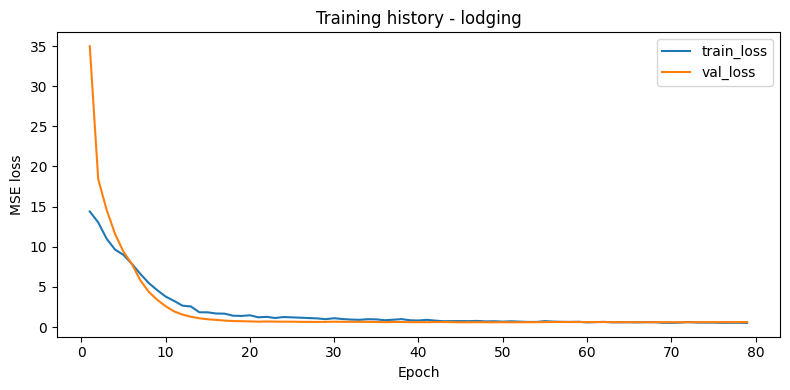

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_training_history_lodging.png


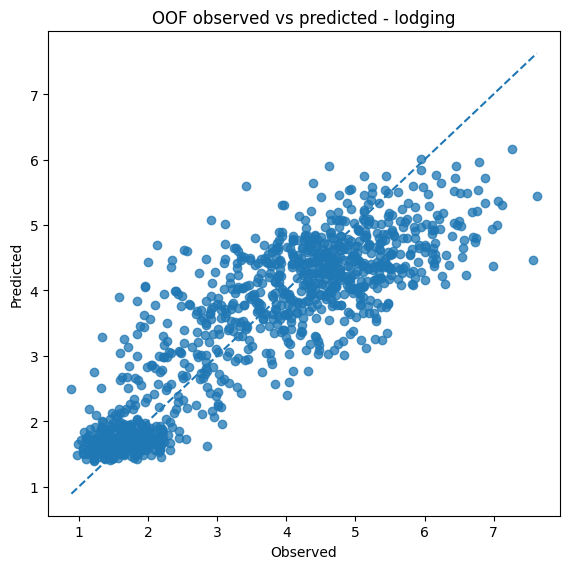

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_scatter_lodging.png


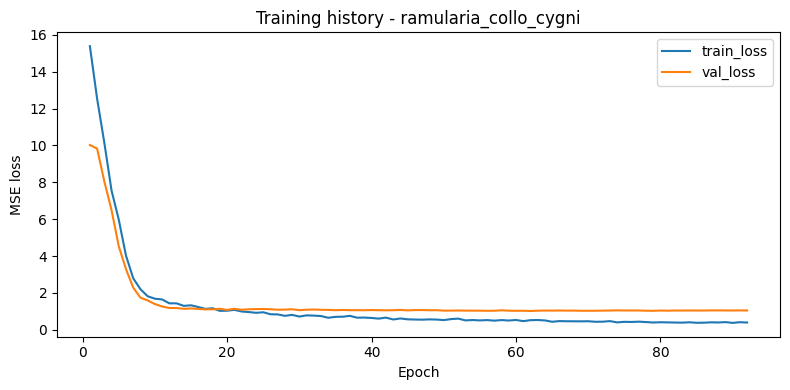

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_training_history_ramularia_collo_cygni.png


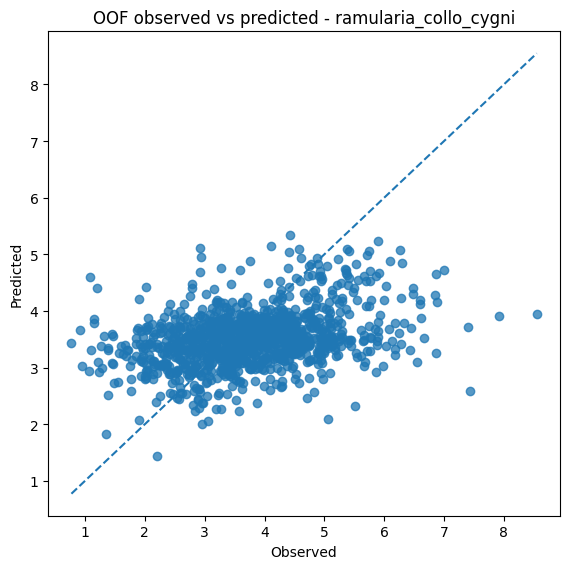

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot\nn_scatter_ramularia_collo_cygni.png


In [10]:
# 11) Curvas de entrenamiento y scatter observado vs predicho (OOF)

def plot_training_history(history_dict, trait, out_path):
    loss = history_dict.get("loss", [])
    val_loss = history_dict.get("val_loss", [])
    epochs = np.arange(1, len(loss) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"Training history - {trait}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()


def plot_oof_scatter(df_trait, trait, out_path):
    y_true = df_trait["y_true"].to_numpy(dtype=float)
    y_pred = df_trait["y_pred"].to_numpy(dtype=float)

    min_v = float(min(np.min(y_true), np.min(y_pred)))
    max_v = float(max(np.max(y_true), np.max(y_pred)))

    plt.figure(figsize=(5.8, 5.8))
    plt.scatter(y_true, y_pred, alpha=0.75)
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"OOF observed vs predicted - {trait}")
    plt.tight_layout()
    plt.savefig(out_path, dpi=170)
    plt.show()


for trait in traits_disponibles:
    best_row = best_by_trait_df.loc[best_by_trait_df["trait"] == trait]
    if best_row.empty:
        continue
    best_row = best_row.iloc[0]

    key = (
        best_row["trait"],
        best_row["model_name"],
        float(best_row["learning_rate"]),
        int(best_row["batch_size"]),
    )

    # Curva del mejor entrenamiento (menor val_loss) dentro del mejor modelo del trait
    runs = history_store.get(key, [])
    if runs:
        best_run = sorted(runs, key=lambda d: d["val_loss_min"])[0]
        history_path = OUTPUT_DIR / f"nn_training_history_{trait}.png"
        plot_training_history(best_run["history"], trait, history_path)
        print(f"Guardado: {history_path}")

    # Scatter OOF del mejor modelo del trait
    trait_oof = oof_df.loc[oof_df["trait"] == trait].copy()
    if not trait_oof.empty:
        scatter_path = OUTPUT_DIR / f"nn_scatter_{trait}.png"
        plot_oof_scatter(trait_oof, trait, scatter_path)
        print(f"Guardado: {scatter_path}")


In [11]:
# 12) Resumen final automático del mejor modelo por trait

def compute_oof_trait_metrics(oof_frame):
    rows = []
    for trait, grp in oof_frame.groupby("trait"):
        m = regression_metrics(grp["y_true"].values, grp["y_pred"].values)
        rows.append({
            "trait": trait,
            "oof_pearson_r": m["pearson_r"],
            "oof_r2": m["r2"],
            "oof_rmse": m["rmse"],
            "oof_mae": m["mae"],
            "oof_n": int(len(grp)),
        })
    return pd.DataFrame(rows)


oof_metrics_df = compute_oof_trait_metrics(oof_df)

final_summary_df = (
    best_by_trait_df
    .merge(oof_metrics_df, on="trait", how="left")
    .sort_values(by=["trait"])
    .reset_index(drop=True)
)

print("=" * 80)
print("RESUMEN FINAL AUTOMÁTICO")
print("=" * 80)
display(final_summary_df)

print("\nArchivos principales generados en:", OUTPUT_DIR)
print("- nn_snp_pilot_results.csv")
print("- nn_snp_pilot_summary.csv")
print("- nn_snp_pilot_oof_predictions.csv")
print("- nn_training_history_lodging.png")
print("- nn_training_history_ramularia_collo_cygni.png")
print("- nn_scatter_lodging.png")
print("- nn_scatter_ramularia_collo_cygni.png")


RESUMEN FINAL AUTOMÁTICO


,trait,model_name,learning_rate,batch_size,n_folds,pearson_r_mean,pearson_r_std,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,best_epoch_mean,oof_pearson_r,oof_r2,oof_rmse,oof_mae,oof_n
0,lodging,mlp_a,0.001,32,5,0.878077,0.009822,0.750505,0.024142,0.787643,0.043086,0.598621,0.038254,95.4,0.872701,0.751799,0.788585,0.598621,1110
1,ramularia_collo_cygni,mlp_a,0.001,16,5,0.366973,0.068748,0.073925,0.060718,1.076593,0.058727,0.833704,0.041104,95.2,0.358741,0.075467,1.077873,0.833704,1110



Archivos principales generados en: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pilot
- nn_snp_pilot_results.csv
- nn_snp_pilot_summary.csv
- nn_snp_pilot_oof_predictions.csv
- nn_training_history_lodging.png
- nn_training_history_ramularia_collo_cygni.png
- nn_scatter_lodging.png
- nn_scatter_ramularia_collo_cygni.png
